In [1]:
import mis
import metric

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [2]:
# get data
images = loadmat('/grid/klindt/data/Neuro/vinken2023/dataverse_files/data/images.mat')
inputs = images['imarray'].copy()
inputs = np.transpose(inputs, (3, 2, 0, 1))
neural = loadmat('/grid/klindt/data/Neuro/vinken2023/dataverse_files/data/neural.mat')
activations = neural['R'].copy().T

inputs.shape, activations.shape

((1379, 3, 224, 224), (1379, 449))

In [3]:
# get metric
dreamsim = metric.DreamSimMetric('cuda')
# cosine = metric.CosineMetric()

/grid/klindt/home/klindt/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-03 19:15:18.235579: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-03 19:15:18.260482: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743722118.288876 1459790 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743722118.297914 1459790 cuda_blas.cc:1418

Using cached ./models


Using cache found in ./models/facebookresearch_dino_main
/grid/klindt/home/klindt/.conda/envs/pytorch/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")
/grid/klindt/home/klindt/.conda/envs/pytorch/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [4]:
# precompute embeddings for metric to speed up (significantly)
dreamsim.precompute(inputs, batch_size=256)

Embedding images.


100%|██████████| 6/6 [00:14<00:00,  2.35s/it]


Computing similarities.
Dreamsim: Precomputed embeddings. Now, use precomputed_similarity with indices!


In [5]:
# Compute MIS
quantiles = np.linspace(0, 0.5, 10)
result = mis.run_psychophysics(
    inputs=inputs,
    activations=activations,
    metrics={'dreamsim': dreamsim},#, 'cosine': cosine},
    quantiles=quantiles,
    num_trials=50
)

100%|██████████| 449/449 [00:23<00:00, 18.77it/s]


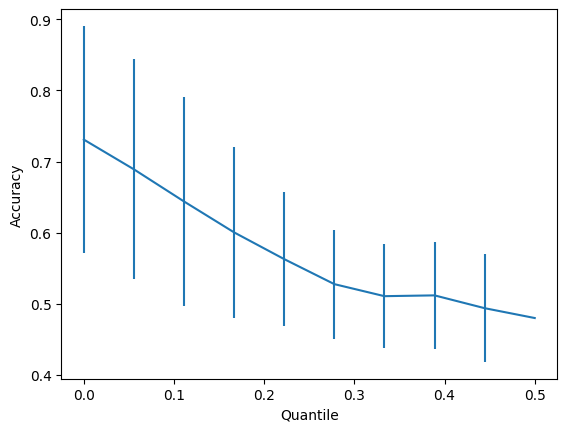

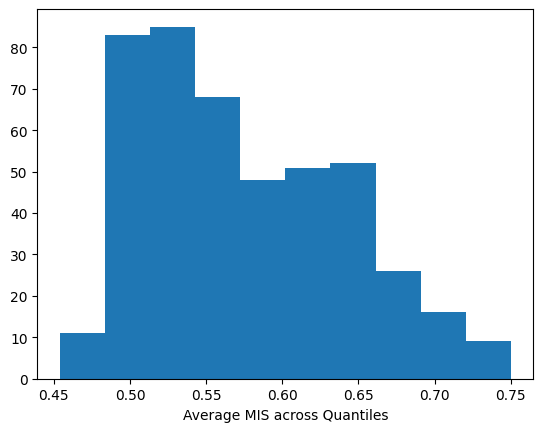

In [7]:
# show results
plt.errorbar(quantiles, result['accuracy_dreamsim'].mean(0), result['accuracy_dreamsim'].std(0))
plt.xlabel('Quantile')
plt.ylabel('Accuracy')
plt.show()

plt.hist(result['accuracy_dreamsim'].mean(1))
plt.xlabel('Average MIS across Quantiles')
plt.show()